# Simulated Annealing

Simulated annealing minimizes an objective while sometimes accepting a worse candidate. Temperature controls how willing the search is to do this: high temperature encourages exploration, while low temperature favors improvement.

Run the cells in order with NumPy and Matplotlib installed. This small example uses a one-dimensional objective so both the landscape and the search history are visible.


## Imports

NumPy supplies vectorized arithmetic and random sampling. Matplotlib draws the objective and the score history.


In [ ]:
# simulated annealing demo
import numpy as np
import matplotlib.pyplot as plt



## Define the Objective

The function returns $f(x)=-(x+\sin x)e^{-x^2}$. Smaller values are better. NumPy lets the same function accept either one candidate or a whole array of sample positions.


In [ ]:
def objective(x):
	return -(x + np.sin(x)) * np.exp(-x**2.0)



## Inspect the Landscape

The plot samples 1,000 points between -5 and 5. The red point and printed values identify the best **sampled** point, not an exact analytic minimum. Use it as a reference for the stochastic search below.


x= 0.68
minimum f(x)= -0.82


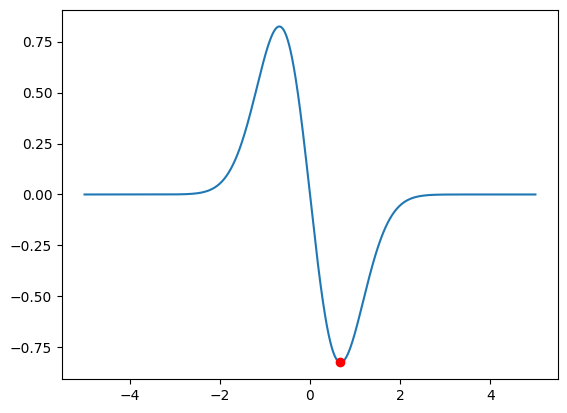

In [ ]:
# draw the landscape of objective function
x = np.linspace(-5, 5, 1000)
y = objective(x)
plt.plot(x, y)
# print the minimum value and its location
index = np.argmin(y)
print('x= {:.2f}'.format(x[index]))
print('minimum f(x)= {:.2f}'.format(y[index]))
# plot the minimum point
plt.plot(x[index], y[index], 'ro')
plt.show()


## Initialize the Search

The initial candidate is uniform on [-5, 5]. The seed line is commented out, so repeated runs can produce different results. The list <code>scores</code> records the objective along the trajectory.


In [ ]:
# simulated annealing algorithm
# the objective is to find the value of x that minimizes the objective function

# set the seed
# np.random.seed(1)

# define the total iterations
n_iter = 1000
# initial guess
x = np.random.uniform(-5, 5)
# run the algorithm
scores = list()


## Propose, Evaluate, and Accept

Each iteration proposes a new point uniformly across the entire interval. This particular demonstration uses global proposals, not a small step around the current point.

An improvement is always accepted. For a worsening change $\Delta=f_{\text{new}}-f_{\text{old}}$, acceptance probability is $e^{-\Delta/T}$. As temperature decreases, a fixed worsening change becomes less likely to pass.

The linear schedule starts at 1 and reaches 0.001 on its final iteration, so this loop never divides by zero. The history appends the score **before** the move; it is neither the post-move score nor a running best.


In [ ]:
for i in range(n_iter):
    T = 1.0 - (i / float(n_iter)) # temperature schedule
    # take a step
    x_new = np.random.uniform(-5, 5)
    # evaluate the objective function
    f_new = objective(x_new)
    f_old = objective(x)
    if f_new < f_old:
        x = x_new
    else:
        p = np.exp((f_old - f_new) / T)
        if np.random.rand() < p:
            x = x_new
    # keep track of scores
    scores.append(f_old)


## Inspect the Final State

The original print labels say "Best," but the code reports the **final** candidate: it does not separately retain the best point ever visited. The history can rise because accepting worse moves is intentional.

Compare the final score with the sampled minimum from the first plot. One run is not a guarantee of finding the global minimum.


Done!
Best x: 0.67
Best score: -0.82


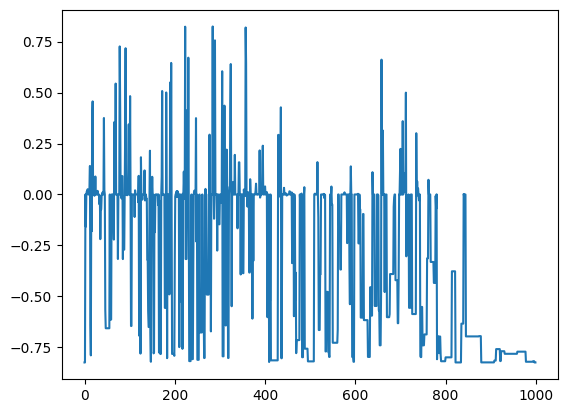

In [ ]:
# print the best result
print('Done!')
print('Best x: {:.2f}'.format(x))
print('Best score: {:.2f}'.format(objective(x)))
# plot scores
plt.plot(scores)
plt.show()

## Experiments

- Repeat the search with a fixed seed, then without one. Which results are reproducible?
- Compare faster and slower cooling. How often does the search still accept worse candidates near the end?
- Consider storing a separate best-so-far candidate. Why would that history never increase even when the current score does?

<details class="notebook-answers">
<summary>Answers and discussion</summary>

1. **Reset the seed before each run.** With the same seed, parameters, and random-call order, the initial point, proposals, acceptance decisions, and trajectory repeat in the same environment. Without reseeding, the random generator advances and the next run generally differs. The separately sampled objective landscape is deterministic and does not depend on this randomness.
2. **Lower temperature suppresses worsening moves.** For the same worsening amount, faster cooling gives a lower acceptance probability at a comparable iteration; slower cooling preserves more exploration. For a worsening amount of 0.2, the probability is about 0.819 at temperature 1 and 0.135 at temperature 0.1. Actual counts depend on the proposed candidates and random draws, so a single run does not establish which schedule is better.
3. **The best-so-far record only accepts improvements.** Initialize a separate best candidate from the starting point, then replace it only when the current candidate has a smaller objective. Its score is the minimum over all candidates visited so far and therefore cannot increase. The current candidate can still worsen under the annealing acceptance rule. Record the updated state so the final move is not omitted.

</details>

**Takeaway:** temperature changes acceptance, while the proposal rule changes which candidates are considered. They are two separate design choices.
